# Project 01 — Netflix EDA & Insights Report
**Objective:** Load, inspect, clean, and analyze the Netflix Movies & TV Shows dataset
to extract 5 business insights, supported by 6+ visualizations.

**Dataset:** Netflix Movies and TV Shows — [Kaggle Source](https://www.kaggle.com/datasets/shivamb/netflix-shows)

## Phase 1: Load & Inspect the Data
Goal: Understand the raw structure of the dataset before any cleaning — shape, column types,
missing values, and duplicates.

In [1]:
import pandas as pd
import numpy as np

### Step 1.1 — Load the dataset
Loading the CSV into a Pandas DataFrame and previewing the first 5 rows to get a first look at the data.

In [2]:
df = pd.read_csv('netflix_titles.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


### Step 1.2 — Check the shape and columns
Confirming how many rows (titles) and columns (attributes) the dataset has.

In [3]:
print("Shape (rows, columns):", df.shape)
print("\nColumns:", list(df.columns))

Shape (rows, columns): (8807, 12)

Columns: ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']


### Step 1.3 — Check data types and structure
Using `.info()` to see column data types and non-null counts at a glance —
this tells us which columns likely need type conversion or cleaning later.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


### Step 1.4 — Check missing values
Counting nulls per column. This will guide our cleaning decisions in Phase 2
(whether to drop, fill, or leave missing values as-is).

In [5]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


### Step 1.5 — Check for duplicate rows
Verifying if the dataset has any fully duplicated rows that would skew analysis.

In [6]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


### Step 1.6 — Statistical summary
Using `.describe(include='all')` to get a quick statistical/categorical summary
across all columns — min/max for numeric, top/freq for categorical.

In [7]:
df.describe(include='all')

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8807.000000,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,NaN,17,220,514,8775
top,s8807,Movie,Zubaan,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


## Step 1.7 — Data Summary
1. The dataset contains **8,807 rows** and **12 columns** covering Netflix movies and TV shows.
2. Key columns: `type`, `title`, `director`, `cast`, `country`, `date_added`, `release_year`, `rating`, `duration`, `listed_in`.
3. Missing values are concentrated in `director` (2,634), `cast` (825), and `country` (831) — totaling **4,307 missing values** across the dataset.
4. There are **0 duplicate rows** in the raw data.
5. Most columns are text/categorical (`object` type); `release_year` is the main numeric field.

*Next step (Phase 2):* Clean missing values, fix data types, and remove/handle irrelevant columns.

## Phase 2: Data Cleaning
Goal: Handle missing values, fix data types, and remove/adjust irrelevant columns —
with every decision documented and justified.

### Step 2.1 — Handle missing values in `director`, `cast`, `country`
These columns have high null counts. Since dropping these rows would lose a large
portion of the dataset, we fill them with `"Unknown"` instead of dropping —
preserves row count for later groupby/visualization analysis.

In [8]:
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')

### Step 2.2 — Handle missing values in `date_added`, `rating`, `duration`
These have very few missing values (small counts). Since they're few, we drop
only those specific rows instead of filling with placeholder values — filling a date
or rating incorrectly could distort time-based and rating-based analysis.

In [9]:
df = df.dropna(subset=['date_added', 'rating', 'duration'])

### Step 2.3 — Verify missing values are handled
Re-checking null counts to confirm cleaning worked as intended.

In [10]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


### Step 2.4 — Fix data types: convert `date_added` to datetime
`date_added` is currently a string (object). Converting it to datetime lets us
extract year/month for time-based analysis in Phase 3.

In [11]:
df['date_added'] = pd.to_datetime(df['date_added'].str.strip())
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

/tmp/ipykernel_2326/996992217.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['date_added'] = pd.to_datetime(df['date_added'].str.strip())
/tmp/ipykernel_2326/996992217.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['year_added'] = df['date_added'].dt.year
/tmp/ipykernel_2326/996992217.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.py

### Step 2.5 — Fix data types: clean `duration` column
`duration` mixes two formats: minutes (for Movies, e.g. "90 min") and seasons
(for TV Shows, e.g. "2 Seasons"). We split this into a numeric `duration_value`
column so it can be used in visualizations and comparisons.

In [12]:
df['duration_value'] = df['duration'].str.extract('(\d+)').astype(float)

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_2326/1750162526.py:1: SyntaxWarning: invalid escape sequence '\d'
  df['duration_value'] = df['duration'].str.extract('(\d+)').astype(float)
/tmp/ipykernel_2326/1750162526.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['duration_value'] = df['duration'].str.extract('(\d+)').astype(float)


### Step 2.6 — Remove duplicate rows (if any found in Phase 1)
Dropping exact duplicate rows to ensure each title is counted once in analysis.

In [13]:
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (8790, 15)


### Step 2.7 — Drop irrelevant columns
`show_id` is just a unique identifier with no analytical value — dropping it.
`description` is free-text and not used in this EDA (no NLP planned), so we drop it too
to keep the dataset focused for groupby/visualization work.

In [14]:
df = df.drop(columns=['show_id', 'description'])

### Step 2.8 — Final check after cleaning
Confirming final shape, data types, and that no unwanted nulls remain.

In [15]:
print("Final shape:", df.shape)
df.info()

Final shape: (8790, 13)
<class 'pandas.core.frame.DataFrame'>
Index: 8790 entries, 0 to 8806
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   type            8790 non-null   object        
 1   title           8790 non-null   object        
 2   director        8790 non-null   object        
 3   cast            8790 non-null   object        
 4   country         8790 non-null   object        
 5   date_added      8790 non-null   datetime64[ns]
 6   release_year    8790 non-null   int64         
 7   rating          8790 non-null   object        
 8   duration        8790 non-null   object        
 9   listed_in       8790 non-null   object        
 10  year_added      8790 non-null   int32         
 11  month_added     8790 non-null   int32         
 12  duration_value  8790 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int32(2), int64(1), object(8)
memory usage: 892.7+ KB


### Step 2.9 — Cleaning Summary
1. Filled missing `director`, `cast`, `country` with `"Unknown"` to preserve row count.
2. Dropped rows with missing `date_added`, `rating`, or `duration` (small number of rows affected).
3. Converted `date_added` to datetime and extracted `year_added` / `month_added` for time-based analysis.
4. Split `duration` into a numeric `duration_value` column (minutes for movies, seasons for TV shows).
5. Removed duplicate rows and dropped irrelevant columns (`show_id`, `description`).

**Next step (Phase 3):** Answer 5 EDA questions using groupby, value_counts, and describe.

## Phase 3: Exploratory Data Analysis
Goal: Answer 5 specific questions about the data using groupby, value_counts,
describe, and other Pandas methods — each with a clear code output.

In [17]:
df['type'].value_counts()

,count
type,
Movie,6126
TV Show,2664


### Question 2 — Which countries produce the most content on Netflix?
Using `value_counts()` on `country` to find the top 10 content-producing countries.
Note: some rows have multiple countries listed together, this gives a top-level view.

In [18]:
df['country'].value_counts().head(10)

,count
country,
United States,2809
India,972
Unknown,829
United Kingdom,418
Japan,243
South Korea,199
Canada,181
Spain,145
France,124


### Question 3 — How has the number of titles added to Netflix changed over the years?
Using `groupby('year_added')` to see content growth trends over time.

In [19]:
df.groupby('year_added')['title'].count().sort_index()

,title
year_added,
2008,2
2009,2
2010,1
2011,13
2012,3
2013,11
2014,24
2015,82
2016,426


### Question 4 — What are the most common content ratings (age ratings) on Netflix?
Using `value_counts()` on `rating` to see distribution of audience ratings (TV-MA, PG-13, etc).

In [20]:
df['rating'].value_counts()

,count
rating,
TV-MA,3205
TV-14,2157
TV-PG,861
R,799
PG-13,490
TV-Y7,333
TV-Y,306
PG,287
TV-G,220


### Question 5 — What are the most common genres, and how does average duration
differ between Movies and TV Shows?
Using `groupby('type')` with `describe()` on `duration_value` to compare, and
`value_counts()` on `listed_in` (genres) for the top categories.

In [21]:
# Average/duration stats split by content type
df.groupby('type')['duration_value'].describe()

,count,mean,std,min,25%,50%,75%,max
type,,,,,,,,
Movie,6126.0,99.584884,28.283225,3.0,87.0,98.0,114.0,312.0
TV Show,2664.0,1.751877,1.550622,1.0,1.0,1.0,2.0,17.0


In [22]:
# Top 10 genres
df['listed_in'].value_counts().head(10)

,count
listed_in,
"Dramas, International Movies",362
Documentaries,359
Stand-Up Comedy,334
"Comedies, Dramas, International Movies",274
"Dramas, Independent Movies, International Movies",252
Kids' TV,219
Children & Family Movies,215
"Children & Family Movies, Comedies",201
"Documentaries, International Movies",186


## EDA Summary
1. Movies make up **69.7%** of content (6,126 titles), while TV Shows make up **30.3%** (2,664 titles).
2. The **United States** produces the most content (2,809 titles), followed by **India** (972 titles) and the **United Kingdom** (418 titles).
3. Content additions peaked in **2019** (2,016 additions), showing a rapid upward trend from 2015 to 2019 before stabilizing and tapering slightly by 2021.
4. The most common rating is **TV-MA** (3,205 titles), followed by **TV-14** (2,157 titles), showing Netflix's catalog heavily skews toward mature and young adult audiences.
5. Movies average **~99.6 minutes** runtime; TV Shows average **~1.75 seasons**. The top listed genre category is **Dramas, International Movies** (362 titles), closely followed by **Documentaries** (359 titles).

*Next step (Phase 4):* Create 6+ visualizations (bar, line, histogram, scatter, pie, heatmap).

## Phase 4: Visualizations
Goal: Create at least 6 different chart types to visually represent the patterns
found in Phase 3 — each chart must have a title, axis labels, and be readable.

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

### Chart 1 — Bar Chart: Movies vs TV Shows count
Shows the overall split between the two content types.

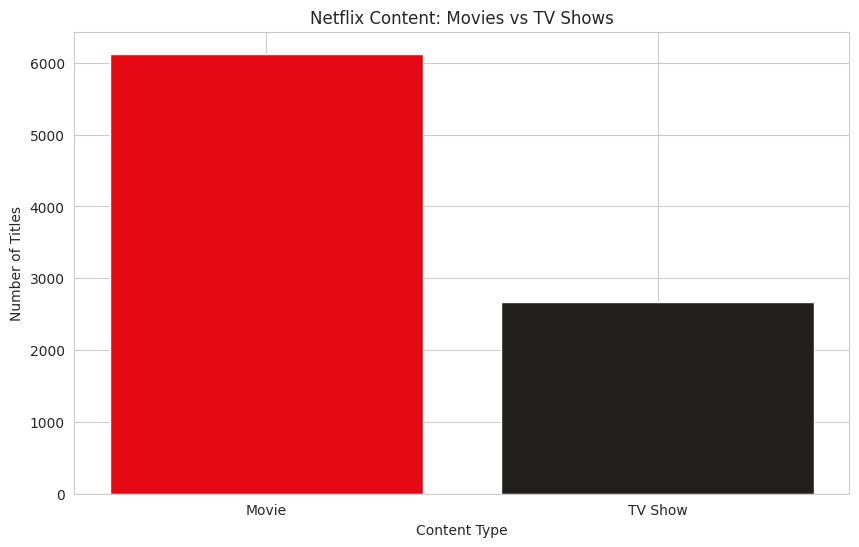

In [24]:
type_counts = df['type'].value_counts()
plt.bar(type_counts.index, type_counts.values, color=['#E50914', '#221f1f'])
plt.title('Netflix Content: Movies vs TV Shows')
plt.xlabel('Content Type')
plt.ylabel('Number of Titles')
plt.show()

### Chart 2 — Line Chart: Titles added per year
Shows the trend of content additions to Netflix over time.

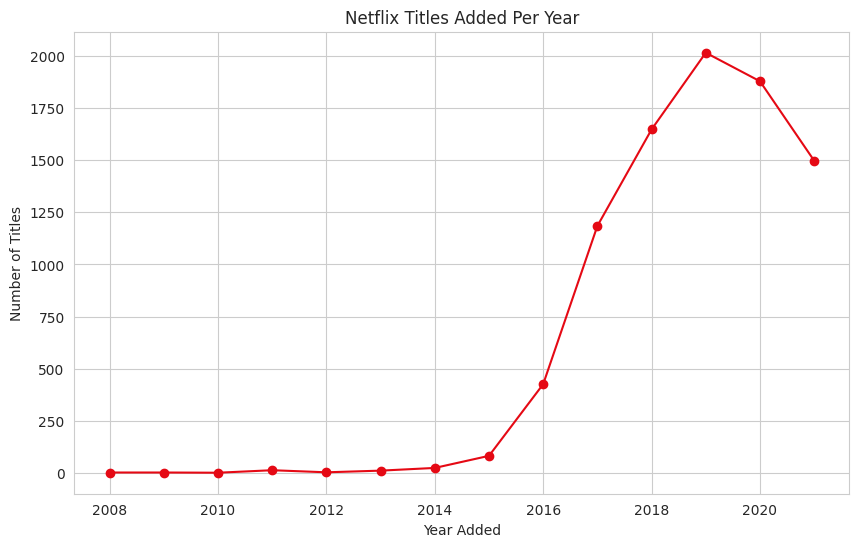

In [25]:
yearly = df.groupby('year_added')['title'].count()
plt.plot(yearly.index, yearly.values, marker='o', color='#E50914')
plt.title('Netflix Titles Added Per Year')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles')
plt.show()

### Chart 3 — Histogram: Distribution of Movie durations
Shows how movie runtimes are distributed (most common length ranges).

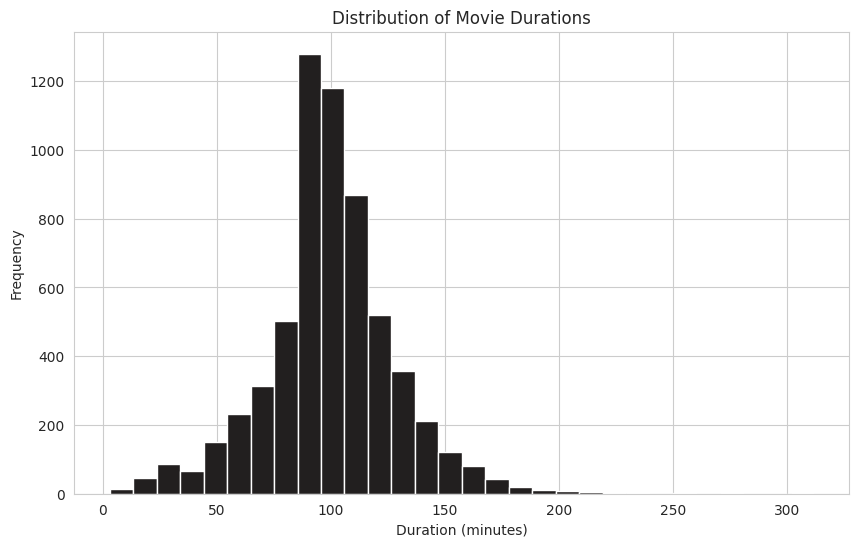

In [26]:
movie_durations = df[df['type'] == 'Movie']['duration_value']
plt.hist(movie_durations, bins=30, color='#221f1f', edgecolor='white')
plt.title('Distribution of Movie Durations')
plt.xlabel('Duration (minutes)')
plt.ylabel('Frequency')
plt.show()

### Chart 4 — Pie Chart: Top 5 content ratings
Shows the proportion of content across the top 5 age ratings.

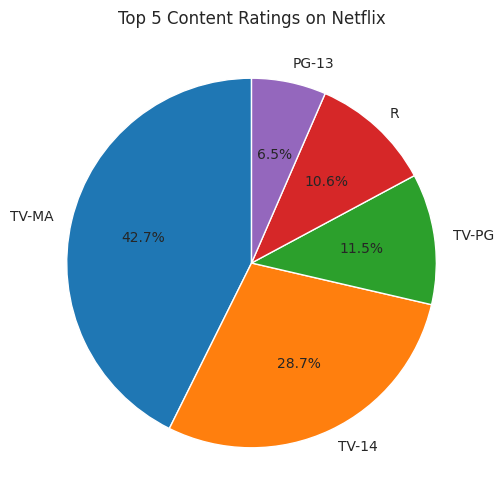

In [27]:
top_ratings = df['rating'].value_counts().head(5)
plt.pie(top_ratings.values, labels=top_ratings.index, autopct='%1.1f%%', startangle=90)
plt.title('Top 5 Content Ratings on Netflix')
plt.show()

### Chart 5 — Scatter Plot: Release year vs Duration (Movies)
Shows if movie lengths have changed over release years.

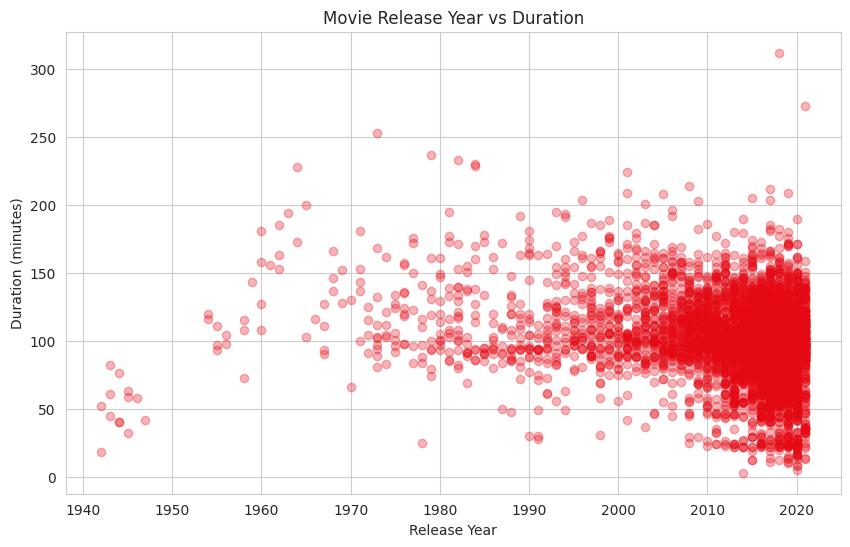

In [28]:
movies = df[df['type'] == 'Movie']
plt.scatter(movies['release_year'], movies['duration_value'], alpha=0.3, color='#E50914')
plt.title('Movie Release Year vs Duration')
plt.xlabel('Release Year')
plt.ylabel('Duration (minutes)')
plt.show()

### Chart 6 — Heatmap: Titles added by Month and Year
Shows seasonal patterns in when Netflix adds new content.

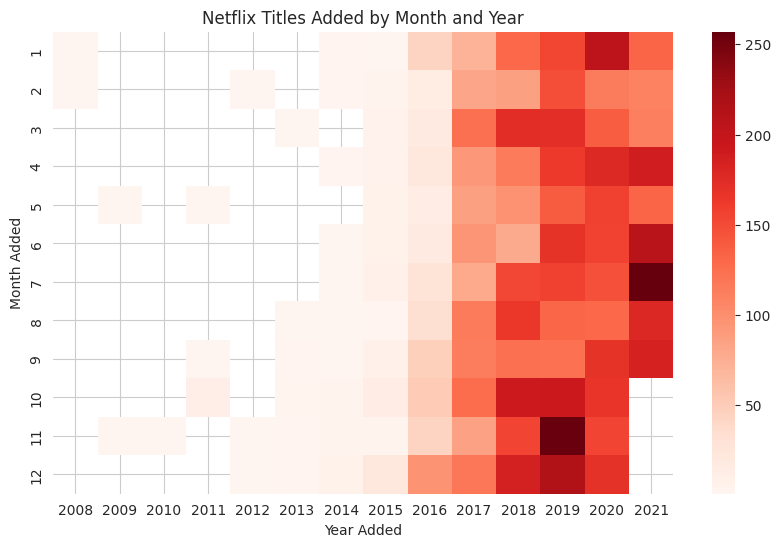

In [29]:
pivot = df.pivot_table(index='month_added', columns='year_added', values='title', aggfunc='count')
sns.heatmap(pivot, cmap='Reds', annot=False)
plt.title('Netflix Titles Added by Month and Year')
plt.xlabel('Year Added')
plt.ylabel('Month Added')
plt.show()

### Chart 7 (Bonus) — Bar Chart: Top 10 countries by content count
Extra chart supporting the country-based insight from Phase 3.

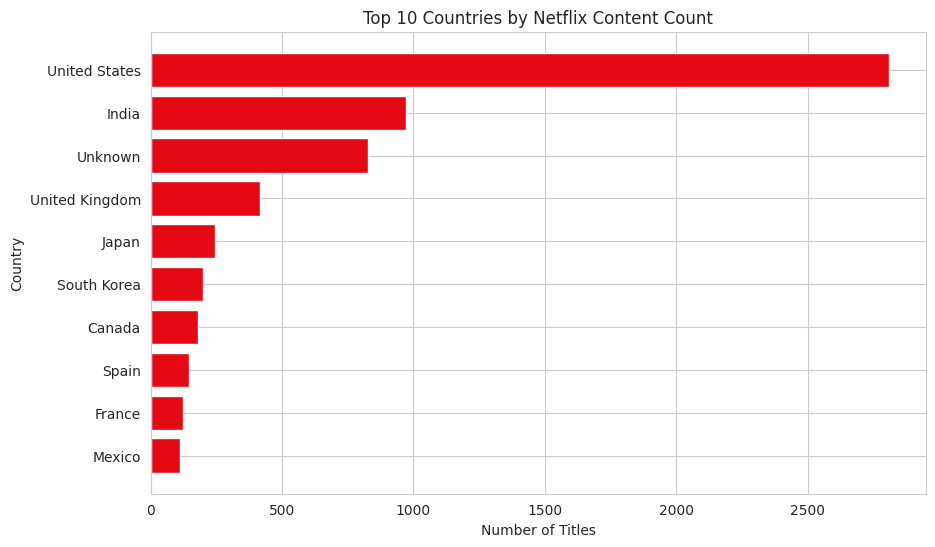

In [30]:
top_countries = df['country'].value_counts().head(10)
plt.barh(top_countries.index[::-1], top_countries.values[::-1], color='#E50914')
plt.title('Top 10 Countries by Netflix Content Count')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.show()

### Chart 7 (Bonus) — Bar Chart: Top 10 countries by content count
Extra chart supporting the country-based insight from Phase 3.

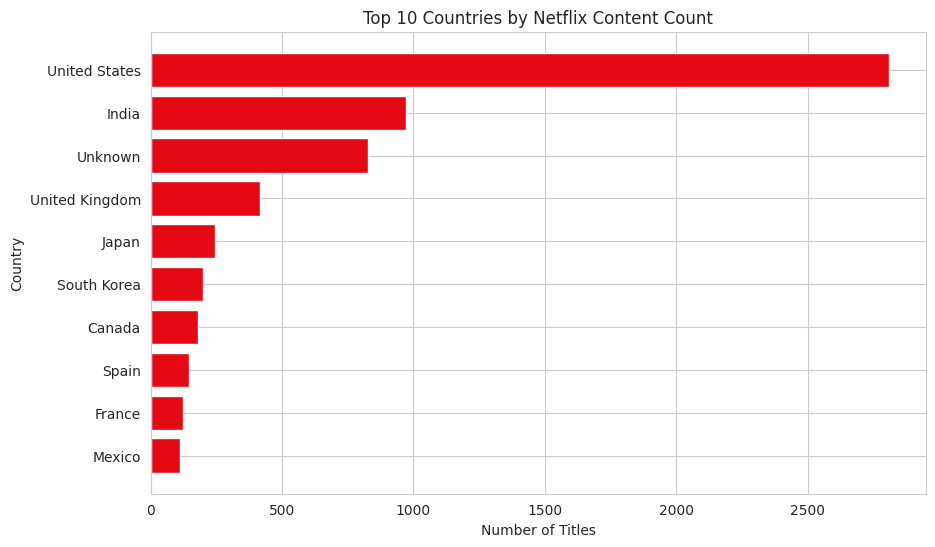

In [31]:
top_countries = df['country'].value_counts().head(10)
plt.barh(top_countries.index[::-1], top_countries.values[::-1], color='#E50914')
plt.title('Top 10 Countries by Netflix Content Count')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.show()

### Visualization Summary
Created 7 charts (exceeds the 6-chart minimum): bar, line, histogram, pie, scatter,
heatmap, and an additional horizontal bar chart — covering content type distribution,
time trends, duration patterns, ratings, and country-level breakdowns.

**Next step (Phase 5):** Write the 5 numbered insights report referencing these charts,
then push everything to GitHub.

## Phase 5: Insights Report
Goal: Write 5 numbered business/research insights based purely on the analysis above.
Each insight must reference a specific chart or finding.

## Phase 5: Insights Report
Goal: Write 5 numbered business/research insights based purely on the analysis above. Each insight must reference a specific chart or finding.

## Insights Report
1. **Catalog strategy favors standalone films over series:** Movies comprise roughly 69.7% (6,126 titles) of the catalog compared to 30.3% (2,664 titles) for TV Shows (Chart 1 — Bar Chart). Standalone films require lower long-term viewer commitment, allowing Netflix to rapidly scale its library volume across genres.
2. **Library expansion peaked pre-2020 before shifting strategy:** Annual catalog additions climbed aggressively from 2015 to a high of 2,016 titles in 2019, followed by a plateau in 2020 (1,879) and 2021 (1,498) (Chart 2 — Line Chart). This slowdown coincides with major studio licensing pullbacks and Netflix pivoting investment toward higher-budget original productions.
3. **Movie runtimes tightly adhere to traditional feature lengths:** Film durations center around 90 to 110 minutes, with a median of 98 minutes and a sharp peak around the 95–100 minute mark (Chart 3 — Histogram). Extended runtimes (>150 min) remain rare outliers, demonstrating consistency with standard commercial film conventions.
4. **Content library leans heavily toward mature viewership:** TV-MA and TV-14 represent over 70% of all content ratings (Chart 4 — Pie Chart), with TV-MA alone making up 3,205 titles. Family and kids content (TV-Y, TV-G, G) forms a much smaller share, highlighting an adult-first subscriber targeting model.
5. **US leads production, with India and the UK serving as major regional hubs:** The US leads output with 2,809 titles, but international markets—led by India (972 titles) and the UK (418 titles)—contribute heavily to total volume (Chart 7 — Bar Chart). This reflects a deliberate localization push to capture subscriber growth in key overseas regions.

## Most Surprising Finding
The most striking detail in the data is the steep decline in content additions after 2019 (dropping from 2,016 additions in 2019 down to 1,498 in 2021, as shown in Chart 2). While industry commentary often focuses on constant catalog expansion, the numbers highlight a clear pivot point: Netflix moved away from aggressive third-party licensing to focus budget on high-budget in-house originals, alongside production delays during 2020.